In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

In [9]:
crudo1 = pd.read_csv("Analisis GAC Full7agosto 2026(TOPS MKT).csv", header=None, low_memory=False)

meses = ["Enero","Febrero","Marzo","Abril","Mayo","Junio","Julio",
         "Agosto","Septiembre","Octubre","Noviembre","Diciembre"]

# Cada indicador esta en una fila distinta del dashboard, con los meses en las columnas 1 a 12
tops = pd.DataFrame({
    "Mes": meses,
    "Afluencia_Piso": crudo1.iloc[3, 1:13].values,
    "Ventas_Plaza":   crudo1.iloc[15, 1:13].values,
    "Visualizaciones": crudo1.iloc[26, 1:13].values,
    "Utilidad":       crudo1.iloc[36, 1:13].values,
    "Rotacion":       crudo1.iloc[45, 1:13].values,
    "Recuperacion_Marca": crudo1.iloc[55, 1:13].values,
})
print("Filas y columnas:", tops.shape)
tops.head()

Filas y columnas: (12, 7)


,Mes,Afluencia_Piso,Ventas_Plaza,Visualizaciones,Utilidad,Rotacion,Recuperacion_Marca
0,Enero,76,6,40478,0.634,0,90%
1,Febrero,64,6,27979,1.333,0,100%
2,Marzo,80,7,28448,1.38,0,72%
3,Abril,43,7,32092,1.35,0,91%
4,Mayo,65,7,62405,0.85,0,92%


In [10]:
for col in tops.columns.drop("Mes"):
    tops[col] = tops[col].astype(str).str.replace("%", "", regex=False)
    tops[col] = pd.to_numeric(tops[col], errors="coerce")

print(tops.dtypes)

Mes                       str
Afluencia_Piso        float64
Ventas_Plaza          float64
Visualizaciones       float64
Utilidad              float64
Rotacion              float64
Recuperacion_Marca    float64
dtype: object


In [11]:
print("Nulos por columna:")
print(tops.isnull().sum())

for col in tops.columns.drop("Mes"):
    tops[col] = tops[col].fillna(round(tops[col].mean(), 2))

print("\nNulos despues de rellenar:", tops.isnull().sum().sum())

Nulos por columna:
Mes                   0
Afluencia_Piso        1
Ventas_Plaza          6
Visualizaciones       6
Utilidad              7
Rotacion              6
Recuperacion_Marca    6
dtype: int64

Nulos despues de rellenar: 0


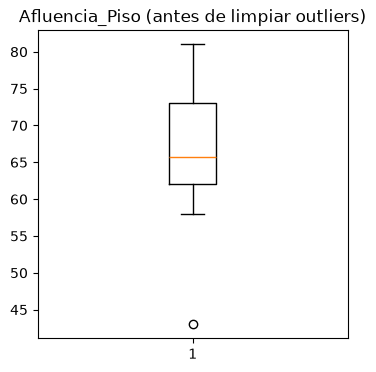

Limite bajo: 45.5  Limite alto: 89.5
Outliers encontrados: 1
Filas finales base 1: 12


In [ ]:
plt.figure(figsize=(4, 4))
plt.boxplot(tops["Afluencia_Piso"])
plt.title("Afluencia_Piso (antes de limpiar outliers)")
plt.show()

q1 = tops["Afluencia_Piso"].quantile(0.25)
q3 = tops["Afluencia_Piso"].quantile(0.75)
iqr = q3 - q1
limite_bajo = q1 - 1.5 * iqr
limite_alto = q3 + 1.5 * iqr
print("Limite bajo:", limite_bajo, " Limite alto:", limite_alto)

es_outlier = (tops["Afluencia_Piso"] < limite_bajo) | (tops["Afluencia_Piso"] > limite_alto)
print("Outliers encontrados:", es_outlier.sum())

if es_outlier.sum() > 0:
    tops.loc[es_outlier, "Afluencia_Piso"] = tops["Afluencia_Piso"].median()

print("Filas finales base 1:", len(tops))

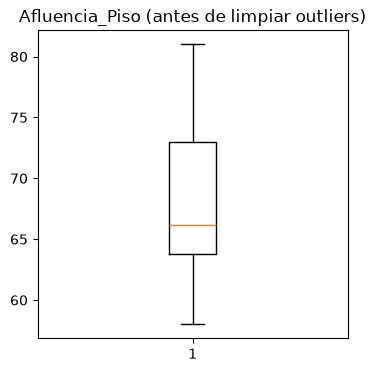

Limite bajo: 49.875  Limite alto: 86.875
Outliers encontrados: 0
Filas finales base 1: 12


In [13]:
plt.figure(figsize=(4, 4))
plt.boxplot(tops["Afluencia_Piso"])
plt.title("Afluencia_Piso (antes de limpiar outliers)")
plt.show()

q1 = tops["Afluencia_Piso"].quantile(0.25)
q3 = tops["Afluencia_Piso"].quantile(0.75)
iqr = q3 - q1
limite_bajo = q1 - 1.5 * iqr
limite_alto = q3 + 1.5 * iqr
print("Limite bajo:", limite_bajo, " Limite alto:", limite_alto)

es_outlier = (tops["Afluencia_Piso"] < limite_bajo) | (tops["Afluencia_Piso"] > limite_alto)
print("Outliers encontrados:", es_outlier.sum())

# Son solo 12 meses, perder una fila afecta mucho el analisis;
# en vez de eliminarla, sustituyo el valor por la mediana.
if es_outlier.sum() > 0:
    tops.loc[es_outlier, "Afluencia_Piso"] = tops["Afluencia_Piso"].median()

print("Filas finales base 1:", len(tops))

                    Afluencia_Piso  Ventas_Plaza  Visualizaciones  Utilidad  \
Afluencia_Piso                1.00         -0.38            -0.12     -0.07   
Ventas_Plaza                 -0.38          1.00            -0.00      0.11   
Visualizaciones              -0.12         -0.00             1.00     -0.69   
Utilidad                     -0.07          0.11            -0.69      1.00   
Rotacion                       NaN           NaN              NaN       NaN   
Recuperacion_Marca           -0.41         -0.34             0.21     -0.20   

                    Rotacion  Recuperacion_Marca  
Afluencia_Piso           NaN               -0.41  
Ventas_Plaza             NaN               -0.34  
Visualizaciones          NaN                0.21  
Utilidad                 NaN               -0.20  
Rotacion                 NaN                 NaN  
Recuperacion_Marca       NaN                1.00  


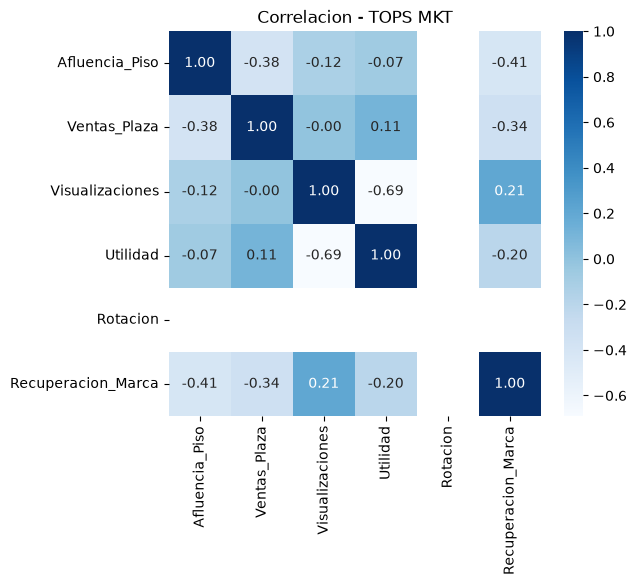

In [14]:
columnas_num = tops.columns.drop("Mes")
correlacion1 = tops[columnas_num].corr()
print(correlacion1.round(2))

plt.figure(figsize=(6, 5))
sns.heatmap(correlacion1, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlacion - TOPS MKT")
plt.show()

Pendiente (m): -0.0491
Interseccion (b): 10.527
r  (correlacion): -0.376
r2 (que tanto explica): 0.142
valor p: 0.22771


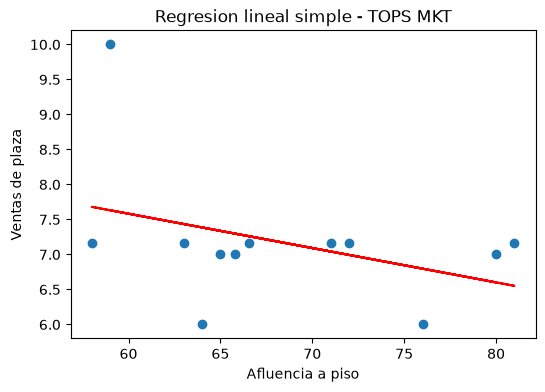

In [15]:
x = tops["Afluencia_Piso"]
y = tops["Ventas_Plaza"]

modelo = linregress(x, y)
print("Pendiente (m):", round(modelo.slope, 4))
print("Interseccion (b):", round(modelo.intercept, 4))
print("r  (correlacion):", round(modelo.rvalue, 3))
print("r2 (que tanto explica):", round(modelo.rvalue ** 2, 3))
print("valor p:", round(modelo.pvalue, 5))

plt.figure(figsize=(6, 4))
plt.scatter(x, y)
plt.plot(x, modelo.intercept + modelo.slope * x, color="red")
plt.xlabel("Afluencia a piso")
plt.ylabel("Ventas de plaza")
plt.title("Regresion lineal simple - TOPS MKT")
plt.show()

In [16]:
crudo2 = pd.read_csv("Analisis GAC Full7agosto 2026(Principales Canales).csv", header=None, low_memory=False)

# Cada canal (Piso, Plazas, Digital) es un bloque de filas con los mismos 30 meses
# (Feb-24 a Jul-26) en las columnas 1 a 30.
def bloque_canal(nombre_canal, fila_leads, fila_sdc, fila_pdm, fila_citas_prog,
                  fila_citas_ef, fila_ventas, fila_conversion, fila_aporte):
    return pd.DataFrame({
        "Canal": nombre_canal,
        "Leads": crudo2.iloc[fila_leads, 1:31].values,
        "SDC": crudo2.iloc[fila_sdc, 1:31].values,
        "PDM": crudo2.iloc[fila_pdm, 1:31].values,
        "Citas_Programadas": crudo2.iloc[fila_citas_prog, 1:31].values,
        "Citas_Efectivas": crudo2.iloc[fila_citas_ef, 1:31].values,
        "Ventas": crudo2.iloc[fila_ventas, 1:31].values,
        "Conversion": crudo2.iloc[fila_conversion, 1:31].values,
        "Aporte": crudo2.iloc[fila_aporte, 1:31].values,
    })

piso    = bloque_canal("Piso",    7,  9, 10, 11, 12, 13, 14, 15)
plazas  = bloque_canal("Plazas", 20, 22, 23, 24, 26, 28, 29, 30)
digital = bloque_canal("Digital",35, 37, 38, 39, 40, 41, 42, 43)

canales = pd.concat([piso, plazas, digital], ignore_index=True)
print("Filas y columnas:", canales.shape)
canales.head()

Filas y columnas: (90, 9)


,Canal,Leads,SDC,PDM,Citas_Programadas,Citas_Efectivas,Ventas,Conversion,Aporte
0,Piso,329,-,22,9,4,9,2.74%,75.00%
1,Piso,19,-,13,28,16,4,21.05%,57.14%
2,Piso,76,-,35,15,6,10,13.16%,125.00%
3,Piso,87,-,40,38,16,1,1.15%,7.69%
4,Piso,55,-,28,78,60,3,5.45%,50.00%


In [17]:
for col in canales.columns.drop("Canal"):
    texto = canales[col].astype(str).str.replace("%", "", regex=False).str.strip()
    texto = texto.replace("-", np.nan)
    canales[col] = pd.to_numeric(texto, errors="coerce")

print(canales.dtypes)

Canal                    str
Leads                  int64
SDC                  float64
PDM                  float64
Citas_Programadas    float64
Citas_Efectivas      float64
Ventas               float64
Conversion           float64
Aporte               float64
dtype: object


In [18]:
print("Nulos por columna:")
print(canales.isnull().sum())

canales["SDC"] = canales["SDC"].fillna(0)

canales = canales.dropna(subset=["Leads", "Ventas", "PDM"]).reset_index(drop=True)
print("\nFilas despues de nulos:", len(canales))

Nulos por columna:
Canal                 0
Leads                 0
SDC                  26
PDM                   9
Citas_Programadas     2
Citas_Efectivas       3
Ventas                4
Conversion            0
Aporte                0
dtype: int64

Filas despues de nulos: 81


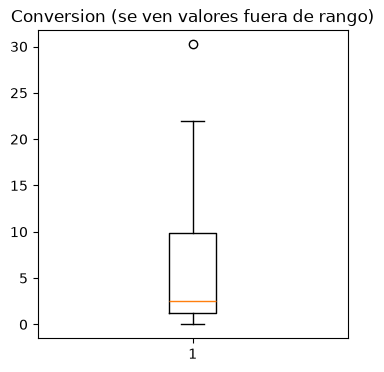

Filas con conversion imposible (>100%): 0
Empty DataFrame
Columns: [Canal, Conversion]
Index: []

Filas finales base 2: 81


In [19]:
plt.figure(figsize=(4, 4))
plt.boxplot(canales["Conversion"])
plt.title("Conversion (se ven valores fuera de rango)")
plt.show()

error_captura = canales["Conversion"] > 100
print("Filas con conversion imposible (>100%):", error_captura.sum())
print(canales.loc[error_captura, ["Canal", "Conversion"]])

canales = canales[~error_captura].reset_index(drop=True)
print("\nFilas finales base 2:", len(canales))

                   Leads   SDC   PDM  Citas_Programadas  Citas_Efectivas  \
Leads               1.00  0.06 -0.13               0.54             0.05   
SDC                 0.06  1.00  0.52               0.50             0.52   
PDM                -0.13  0.52  1.00               0.48             0.65   
Citas_Programadas   0.54  0.50  0.48               1.00             0.81   
Citas_Efectivas     0.05  0.52  0.65               0.81             1.00   
Ventas              0.17  0.59  0.59               0.46             0.43   
Conversion         -0.54  0.13  0.33              -0.12             0.19   
Aporte             -0.04  0.13  0.31               0.10             0.06   

                   Ventas  Conversion  Aporte  
Leads                0.17       -0.54   -0.04  
SDC                  0.59        0.13    0.13  
PDM                  0.59        0.33    0.31  
Citas_Programadas    0.46       -0.12    0.10  
Citas_Efectivas      0.43        0.19    0.06  
Ventas               1.00  

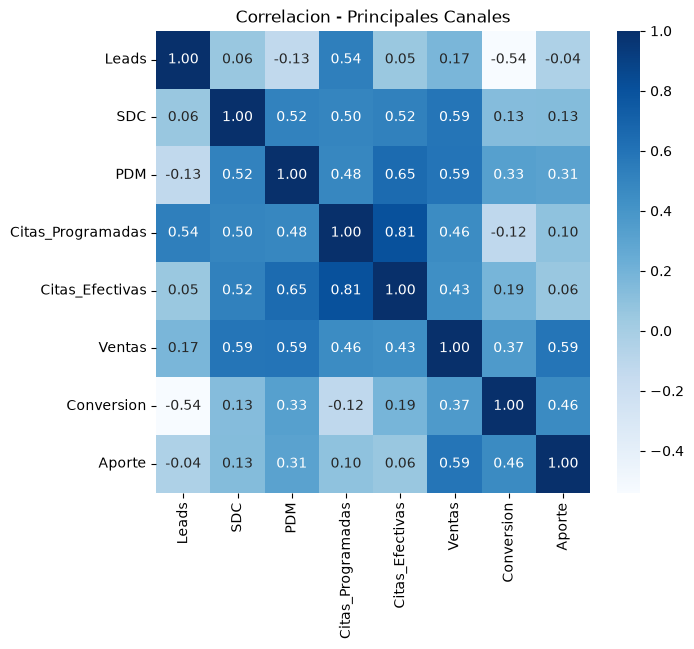

In [20]:
columnas_num = ["Leads", "SDC", "PDM", "Citas_Programadas", "Citas_Efectivas",
                 "Ventas", "Conversion", "Aporte"]
correlacion2 = canales[columnas_num].corr()
print(correlacion2.round(2))

plt.figure(figsize=(7, 6))
sns.heatmap(correlacion2, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlacion - Principales Canales")
plt.show()

Pendiente (m): 0.0022
Interseccion (b): 6.6645
r  (correlacion): 0.17
r2 (que tanto explica): 0.029
valor p: 0.128329


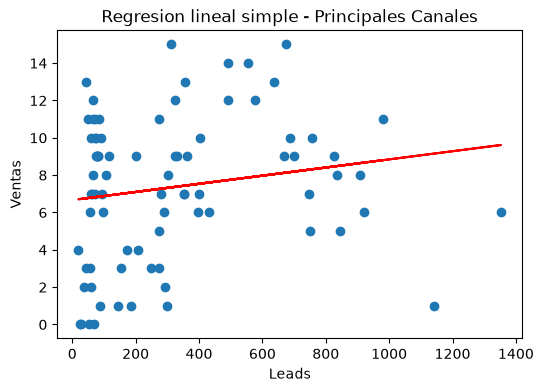

In [21]:
x2 = canales["Leads"]
y2 = canales["Ventas"]

modelo2 = linregress(x2, y2)
print("Pendiente (m):", round(modelo2.slope, 4))
print("Interseccion (b):", round(modelo2.intercept, 4))
print("r  (correlacion):", round(modelo2.rvalue, 3))
print("r2 (que tanto explica):", round(modelo2.rvalue ** 2, 3))
print("valor p:", round(modelo2.pvalue, 6))

plt.figure(figsize=(6, 4))
plt.scatter(x2, y2)
plt.plot(x2, modelo2.intercept + modelo2.slope * x2, color="red")
plt.xlabel("Leads")
plt.ylabel("Ventas")
plt.title("Regresion lineal simple - Principales Canales")
plt.show()